In [22]:
import numpy as np
import matplotlib.pyplot as plt

from scipy.io import loadmat
from scipy.optimize import minimize

In [38]:
def loadMovieList():
    with open("movie_ids.txt", encoding="ISO-8859-1") as fid:
        movies = fid.readlines()

    movieNames = []

    for movie in movies:
        parts = movie.split()
        movieNames.append(" ".join(parts[1:]).strip())

    return movieNames


names = loadMovieList()

In [43]:
movieNames = loadMovieList()
print(movieNames[:10])

['Toy Story (1995)', 'GoldenEye (1995)', 'Four Rooms (1995)', 'Get Shorty (1995)', 'Copycat (1995)', 'Shanghai Triad (Yao a yao yao dao waipo qiao) (1995)', 'Twelve Monkeys (1995)', 'Babe (1995)', 'Dead Man Walking (1995)', 'Richard III (1995)']


In [17]:
movie_names = loadMovieList()
data = loadmat("movies.mat")
Y = data["Y"]
R = data["R"]
print(Y.shape)
print(R.shape)

(1682, 943)
(1682, 943)


In [18]:
print("Movie:", movie_names[0])
print("Average rating:",
      np.mean(Y[0, R[0]==1]))

Movie: Toy Story (1995)
Average rating: 3.8783185840707963


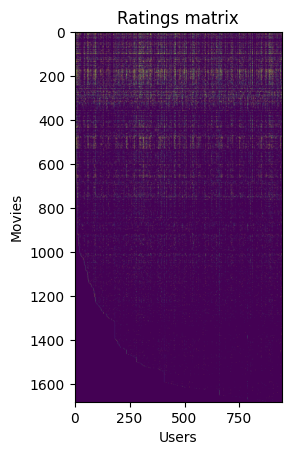

In [13]:
plt.imshow(Y)
plt.xlabel("Users")
plt.ylabel("Movies")
plt.title("Ratings matrix")
plt.grid(False)
plt.show()

In [29]:
def cofi_cost_func(params,Y,R,num_users,num_movies,num_features,lambda_):

    X = params[:num_movies*num_features].reshape(num_movies,num_features)
    Theta = params[num_movies*num_features:].reshape(num_users,num_features)
    prediction = X @ Theta.T
    error = (prediction - Y) * R
    J = 0.5 * np.sum(error**2)
    J += lambda_/2 * (np.sum(Theta**2) + np.sum(X**2))
    return J

In [32]:
def cofi_gradient(params,Y,R,num_users,num_movies,num_features,lambda_):

    X = params[:num_movies*num_features].reshape(num_movies,num_features)
    Theta = params[num_movies*num_features:].reshape(num_users,num_features)
    error = (X @ Theta.T - Y) * R
    X_grad = error @ Theta + lambda_ * X
    Theta_grad = error.T @ X + lambda_ * Theta
    grad = np.concatenate([X_grad.ravel(),Theta_grad.ravel()])
    return grad

In [50]:
num_movies, num_users = Y.shape
num_features = 10
X = np.random.randn(num_movies,num_features)
Theta = np.random.randn(num_users,num_features)
initial_params = np.concatenate([X.ravel(),Theta.ravel()])

In [51]:
result = minimize(
    fun=cofi_cost_func,
    x0=initial_params,
    args=(Y,R,num_users,num_movies,num_features,10),
    jac=cofi_gradient,method="CG",options={"maxiter":100}
)

In [52]:
params = result.x

X = params[:num_movies*num_features].reshape(num_movies,num_features)

Theta = params[num_movies*num_features:].reshape(num_users,num_features)

In [36]:
predictions = X @ Theta.T

In [41]:
user = 10

scores = predictions[:, user]

top = np.argsort(scores)[::-1][:10]

for i in top:
    print(f"{scores[i]:.2f}  {names[i]}")

4.54  Close Shave, A (1995)
4.49  Evita (1996)
4.46  Fargo (1996)
4.46  Sense and Sensibility (1995)
4.46  Schindler's List (1993)
4.43  L.A. Confidential (1997)
4.40  Lone Star (1996)
4.39  Casablanca (1942)
4.38  Amistad (1997)
4.33  Apt Pupil (1998)


In [40]:
rmse = np.sqrt(np.mean(((predictions - Y) * R) ** 2))

print("RMSE =", rmse)

RMSE = 0.20142428032575677


In [44]:
movieList = loadMovieList()

In [45]:
movies_id_list = [0, 97, 6, 11, 53, 63, 65, 68, 182, 225, 354]

for movie in movies_id_list:
    print(movie, "-", movieList[movie])

0 - Toy Story (1995)
97 - Silence of the Lambs, The (1991)
6 - Twelve Monkeys (1995)
11 - Usual Suspects, The (1995)
53 - Outbreak (1995)
63 - Shawshank Redemption, The (1994)
65 - While You Were Sleeping (1995)
68 - Forrest Gump (1994)
182 - Alien (1979)
225 - Die Hard 2 (1990)
354 - Sphere (1998)


In [46]:
my_ratings = np.zeros(num_movies)

my_ratings[0] = 5
my_ratings[97] = 2
my_ratings[6] = 3
my_ratings[11] = 5
my_ratings[53] = 4
my_ratings[63] = 5
my_ratings[65] = 3
my_ratings[68] = 5
my_ratings[182] = 4
my_ratings[225] = 5
my_ratings[354] = 4

In [48]:
Y = np.c_[my_ratings, Y]

R = np.c_[my_ratings != 0, R]

In [49]:
num_movies, num_users = Y.shape

In [53]:
predictions = X @ Theta.T

my_predictions = predictions[:, 0]

top = np.argsort(my_predictions)[::-1]

In [54]:
print("Top:\n")
count = 0
for i in top:
    if my_ratings[i] == 0:
        print(f"{my_predictions[i]:.2f} -> {movieList[i]}")
        count += 1
    if count == 10:
        break

Top:

4.29 -> Titanic (1997)
4.15 -> Star Wars (1977)
4.06 -> Raiders of the Lost Ark (1981)
3.91 -> Braveheart (1995)
3.86 -> Good Will Hunting (1997)
3.86 -> Empire Strikes Back, The (1980)
3.86 -> Return of the Jedi (1983)
3.82 -> Schindler's List (1993)
3.77 -> Terminator 2: Judgment Day (1991)
3.75 -> Air Force One (1997)
